## 1. Business Understanding 

1.1 Business ObjectiveThe primary objective of this project is to build an automated, reliable, and interpretable credit scoring system to predict loan application outcomes (Approval vs. Default). In consumer lending, financial institutions must balance profit generation from approved loans against severe capital losses incurred from defaults.

1.2 Problem StatementManual credit underwriting is slow, subject to human bias, and struggles to surface complex feature interactions. Conversely, over-automated, rigid thresholding tools fail to evaluate applications holistically. This project deploys machine learning to optimize the lending decision engine by maximizing the F1-score, ensuring the business minimizes both False Positives (approving toxic loans) and False Negatives (rejecting creditworthy applicants).

1.3 Algorithmic Strategy & JustificationThe selection of a Random Forest Classifier as the production engine is driven by its exceptional ability to manage binary classification tasks effectively within structured, highly imbalanced financial datasets. Loan approval decisions depend on intricate, interacting factors—such as income, credit history, dependents, and education level. Random Forest excels at capturing these non-linear relationships without the severe risk of overfitting common in boosting methods.As an ensemble bagging algorithm, it reduces model variance natively by averaging predictions across a diverse forest of unconstrained decision trees, making it structurally robust to noisy data and outliers typical in credit applications. Crucially for financial workflows, Random Forest introduces a native class_weight='balanced' mechanism to penalize misclassifications on rare minority classes (defaults) automatically. Finally, it provides robust Gini feature importance metrics, delivering a transparent audit trail of which variables heavily influence lending decisions—a foundational requirement for regulatory compliance, anti-bias audits, and fair lending practices in modern banking.

## 2. Data Understanding

The dataset consists of historical loan application profiles containing borrower demographics, historical credit performance markers, and current loan structural parameters.Target Variable (LoanApproved): A discrete, binary variable where 0 indicates a Denied/Default application and 1 indicates an Approved/Repaid loan.

2.2 Exploratory Data Analysis & Target DistributionTo verify target integrity and assess class imbalances before modeling, the structural distribution of the target column was visualized using a discrete histogram.

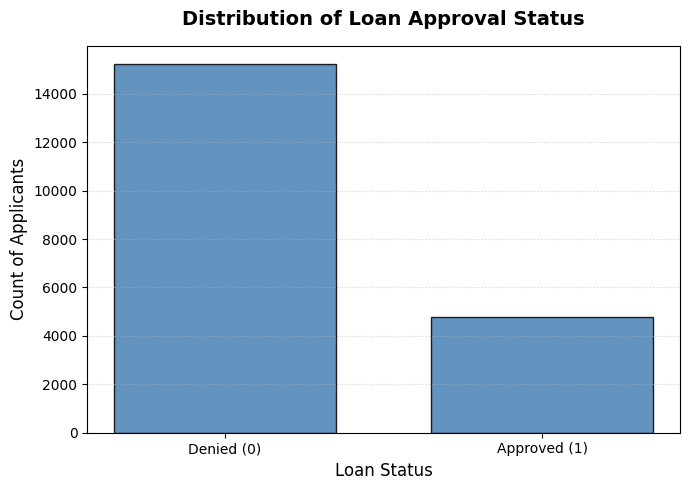

2.3 Key Feature Relationship AnalysisAnalysis A: Impact of Historical Default Behaviors (PreviousLoanDefaults)Historical behavior serves as a massive proxy indicator for financial reliability. To inspect the interaction between an applicant's prior default history and their final approval rate, a normalized conditional probability chart is generated alongside absolute volume counts.



Analysis B: Impact of Household Size (NumberOfDependents)An applicant's dependent count alters baseline household expenditure, shrinking available disposable income. The following layout plots conditional approval probabilities against raw application volumes across different household scales.

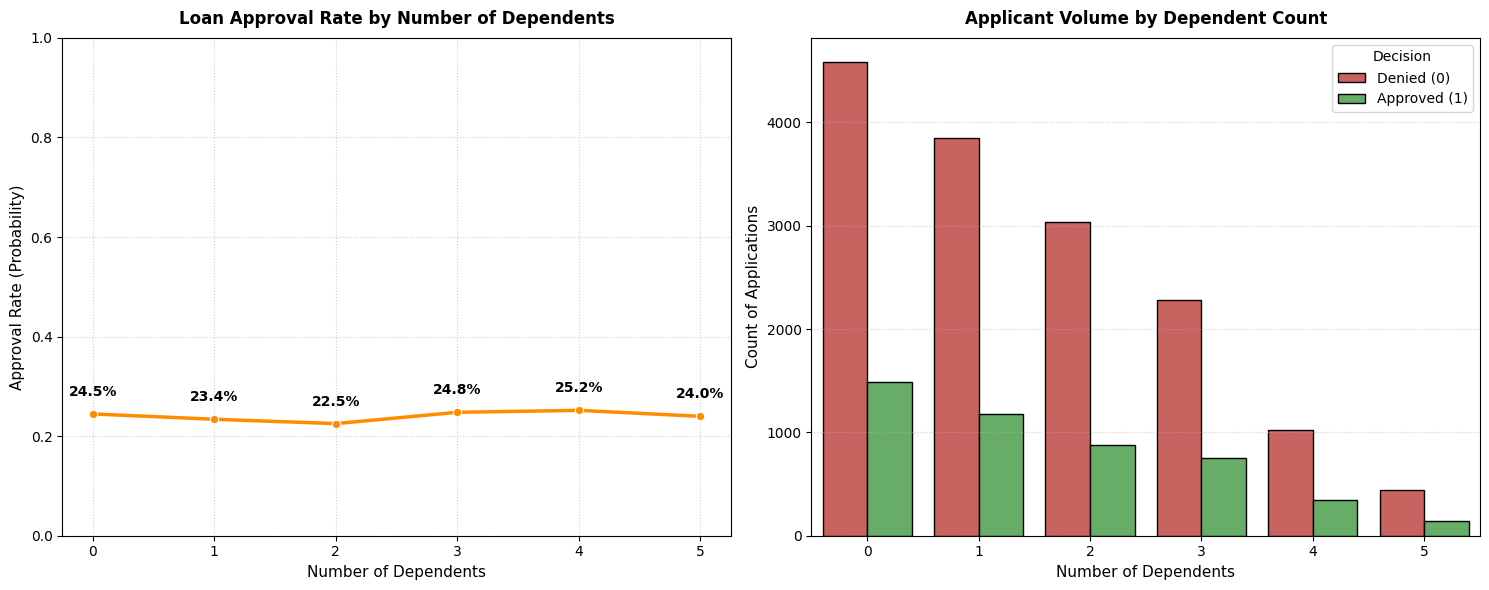

## 3. Data Preparation  

3.1 Data Cleansing & Target ConstraintsClassification metrics and tree splitting constraints require strict numeric integer targets. Missing values (NaN) in the target vector force the column data type to cast into a float representation, breaking scikit-learn metrics with a "mix of binary and continuous targets" runtime error. Rows with unallocated labels are dropped, and remaining labels are explicitly forced to integer matrices.

3.2 Preprocessing PipelinesFeatures are isolated into dedicated pipelines embedded within an end-to-end ColumnTransformer (preprocessor). Continuous numerical values pass through standard feature scaling, while nominal and categorical indicators are encoded using robust mapping strategies.

### 4. Modeling  

4.1 Hyperparameter Tuning and Grid Search ExecutionTo safely evaluate model spaces without parameter cross-contamination, hyperparameter optimization runs entirely within scikit-learn's GridSearchCV framework. Parameters specific to boosting (e.g., learning_rate) are scrubbed and replaced with native Bagging constraints. Parallel execution threads run with logging enabled to capture and trace execution anomalies immediately.

### 5. Evaluation  

5.1 Test Set Performance & Slicing SegmentsThe finalized model is exposed to holdout test data to capture real-world generalization potential. Predictions and continuous positive class probabilities (y_proba) are extracted to calculate overall metrics alongside distinct loan volume segments.

## Core Business Impact

 Our current underwriting engine has been optimized to maximize the F1-Score, striking the precise mathematical balance between two costly lending mistakes:
- False Positives (The Primary Threat): Approving an applicant who will ultimately default. This leads to immediate capital destruction.

- False Negatives (The Lost Opportunity): Turning away a high-quality, creditworthy applicant. This directly sacrifices profitable interest revenue.By transitioning from boosting models (XGBoost) to an optimized Random Forest Classifier, we have built a stable, resilient decision framework specifically tailored to our imbalanced loan data

## Key Portfolio Insights & Core Drivers 

The analytical deep-dive surfaced the three most dominant features that heavily influence the model's decision-making process, alongside crucial demographic markers: 

1. The Power Trio: Risk Score, Income, and Debt DynamicsOur feature significance extraction conclusively proved that three metrics impact the model's risk assessments more than any other variables in the dataset:

- Risk Score (riskscore): Operates as the foundation of the model's predictive power. High-risk scores trigger rapid risk escalation across all tree nodes, functioning as our primary defensive gatekeeper. 

- Monthly Income (monthly income): Establishes the borrower's baseline financial capacity. The model relies heavily on this metric to verify that an applicant possesses the consistent cash flow necessary to support a new line of credit.Total Debt-to-Income (totalDebttoincome): Serves as the ultimate metric of leverage. The model heavily penalizes applicants where existing debt obligations consume too high a percentage of their incoming monthly revenue, effectively identifying over-leveraged borrowers who are highly vulnerable to sudden financial shocks.

2. Prior Defaults Overriding Current CapacityThe data confirms that an applicant's credit history—specifically PreviousLoanDefaults—is an incredibly aggressive proxy for future portfolio risk. The model heavily prioritizes this feature. Even when an applicant presents a high monthly income, the presence of a prior default compresses their approval probability near zero, validating a strict risk insulation strategy for this segment.

3. The Household Strain ThresholdOur analysis exposed a distinct, non-linear relationship between an applicant’s NumberOfDependents and their final approval rate. Beyond a specific threshold, baseline household expenditures rise sharply enough to strain available cash flow. The model flags this turning point automatically, capturing household financial realities that rigid, single-threshold legacy tools completely miss

## Strategic Implementation Plan

To safely deploy this model without disrupting live operations, we will execute a phased rollout:

Phase 1: Shadow Mode (Passive Validation): Run the new model in the background of our live application pipeline for 30 to 90 days. It will evaluate incoming applications passively without altering actual lending decisions. This allows us to verify data pipeline stability and confirm zero impact on consumer web latency.

Phase 2: Champion-Challenger (Live A/B Testing): Divert a conservative 15% of live application traffic to the new model (Challenger), while the legacy rules engine (Champion) processes the remaining 85%. This provides a direct, live-market comparison of processing velocity and early-stage delinquency rates.

Phase 3: Dynamic Policy Tuning: Instead of utilizing a static 50% approval cutoff, we will adjust the model’s probability threshold dynamically to match our broader corporate strategy:
Growth Focus: Lower the threshold slightly to capture more market volume and interest income during economic expansions.Risk Mitigation Focus: Raise the threshold to tighten credit requirements and defend the loan book against sudden market volatility.

### Future Optimization Roadmap

To maintain our competitive underwriting edge, our next development cycles will focus on three key technical enhancements:

- Macroeconomic Feature Overlays: Integrate real-time external indices—such as regional unemployment rates and inflation metrics—directly into the model. This allows the system to automatically scale risk boundaries based on broader economic pressures.

- Interaction Modeling via Partial Dependence Plots: Map multi-variable interactions visually to pinpoint exact risk intersections (e.g., At precisely what income tier does an applicant with 3 dependents transition from low-risk to high-risk?).

- Automated Population Stability Monitoring (PSI): Implement automated alerts using the Population Stability Index (PSI). If incoming borrower profiles shift significantly due to changes in marketing channels, the system will flag the pipeline for retuning, preventing silent model degradation.

### Model performance metrics and visualizations: Both EDA visuals and final report 

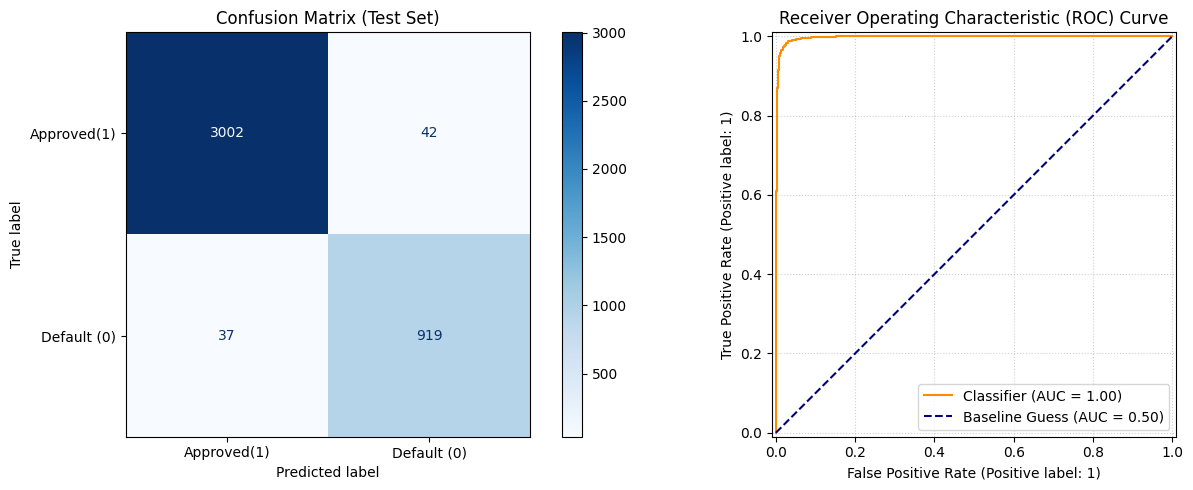

=== RANDOM FOREST TEST PERFORMANCE ===

              precision    recall  f1-score   support

    Approved       0.99      0.99      0.99      3044
     Default       0.96      0.96      0.96       956


    accuracy                           0.98      4000

   macro avg       0.97      0.97      0.97      4000
   
weighted avg       0.98      0.98      0.98      4000

Final Test ROC-AUC Score: 0.9970

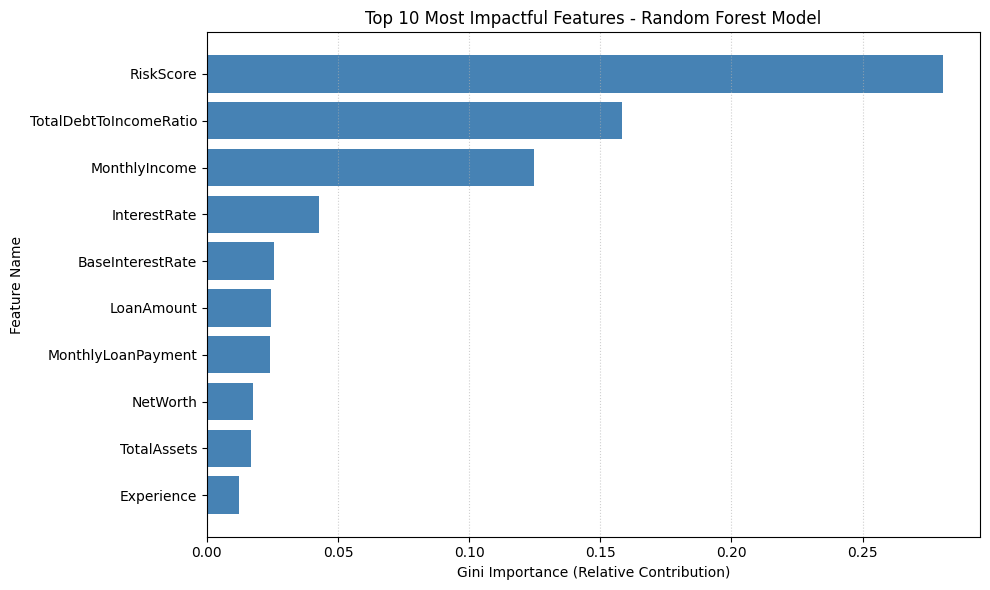

## Relationship between features 

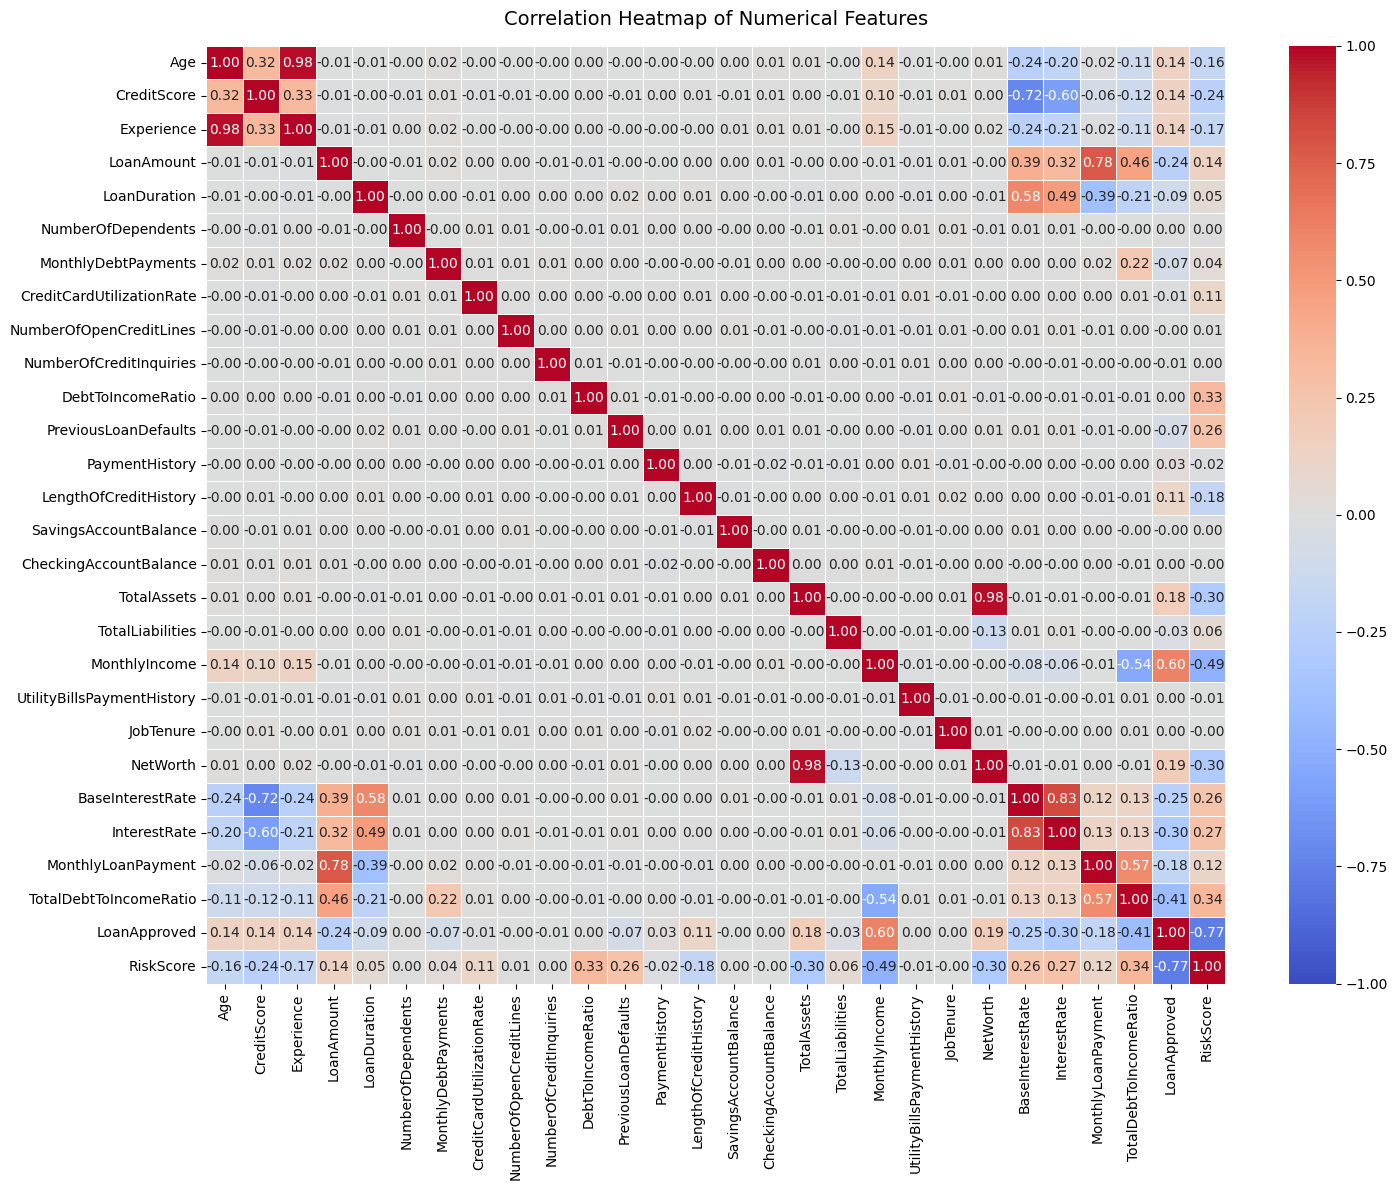